In [7]:
!pip install imbalanced-learn xgboost joblib

In [8]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Handle Class Imbalance
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [9]:
from google.colab import files

uploaded = files.upload()

Saving neo.csv to neo.csv


In [10]:
df = pd.read_csv("neo.csv")

In [11]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [12]:
df.tail()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False
90835,54205447,(2021 TW7),0.039862,0.089133,27024.455553,5.977213e+07,Earth,False,24.12,False


In [13]:
print("Rows and Columns:", df.shape)

Rows and Columns: (90836, 10)


In [14]:
print(df.columns)

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [16]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [17]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

print(df.shape)

(90836, 10)


In [20]:
df.sample(10)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
73856,3170204,(2003 YS17),0.127220,0.284472,42750.631700,1.987680e+07,Earth,False,21.60,True
39375,3143095,(2002 VU114),0.073207,0.163697,26899.593212,6.275743e+07,Earth,False,22.80,False
36334,3580965,(2011 TP),0.013322,0.029788,35736.620483,2.816906e+06,Earth,False,26.50,False
4167,3137735,(2002 TX59),0.044112,0.098637,18877.378440,3.758137e+07,Earth,False,23.90,False
56524,3837866,(2019 AV11),0.040230,0.089958,11773.162497,3.589152e+07,Earth,False,24.10,False
56292,54101673,(2020 YJ2),0.008965,0.020047,64825.376243,1.895771e+07,Earth,False,27.36,False
40060,3647735,(2013 RE36),0.038420,0.085909,97964.286304,3.476160e+07,Earth,False,24.20,False
30283,2209215,209215 (2003 WP25),0.038420,0.085909,26576.010305,1.679225e+07,Earth,False,24.20,False
46890,3542555,(2010 PQ10),0.121494,0.271669,65700.119814,7.180300e+07,Earth,False,21.70,False
32295,3771640,(2017 FA3),0.006677,0.014929,81106.767052,5.386304e+07,Earth,False,28.00,False


In [21]:
df.head()
df.columns

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')

In [22]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [23]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [24]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

In [25]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [26]:
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [27]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [28]:
df = df.drop_duplicates()

In [29]:
print(df.shape)

(90836, 10)


In [30]:
df.dtypes

,0
id,int64
name,object
est_diameter_min,float64
est_diameter_max,float64
relative_velocity,float64
miss_distance,float64
orbiting_body,object
sentry_object,bool
absolute_magnitude,float64
hazardous,bool


In [31]:
df = df.drop(["id", "name"], axis=1)

In [32]:
df.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [33]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

In [34]:
df["orbiting_body"] = label_encoder.fit_transform(df["orbiting_body"])

df["sentry_object"] = label_encoder.fit_transform(df["sentry_object"])

In [35]:
df["hazardous"] = df["hazardous"].astype(int)

In [36]:
df.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,0,0,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,0,0,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,0,0,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,0,0,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,0,0,20.09,1


In [37]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

Index([], dtype='object')

In [38]:
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,0,0,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,0,0,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,0,0,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,0,0,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,0,0,20.09,1


In [39]:
df['hazardous'].value_counts()

,count
hazardous,
0,81996
1,8840


In [40]:
X = df.drop("hazardous", axis=1)

y = df["hazardous"]

In [41]:
print(X.shape)

print(y.shape)

(90836, 7)
(90836,)


In [42]:
from sklearn.preprocessing import StandardScaler

features = [
    'est_diameter_min',
    'est_diameter_max',
    'relative_velocity',
    'miss_distance',
    'orbiting_body',
    'sentry_object',
    'absolute_magnitude'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [43]:
X_scaled

array([[ 3.58728394,  3.58728394, -1.36391312, ...,  0.        ,
         0.        , -2.34863167],
       [ 0.46352912,  0.46352912,  1.00903999, ...,  0.        ,
         0.        , -1.21873486],
       [ 1.9918872 ,  1.9918872 ,  2.61698337, ...,  0.        ,
         0.        , -1.96854406],
       ...,
       [-0.31984203, -0.31984203, -1.60122795, ...,  0.        ,
         0.        ,  0.37072244],
       [-0.4023702 , -0.4023702 ,  0.83549218, ...,  0.        ,
         0.        ,  1.47643186],
       [-0.29335902, -0.29335902, -0.83194291, ...,  0.        ,
         0.        ,  0.20486602]])

In [44]:
X = pd.DataFrame(X_scaled, columns=X.columns)

X.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,3.587284,3.587284,-1.363913,0.795153,0.0,0.0,-2.348632
1,0.463529,0.463529,1.009040,1.090357,0.0,0.0,-1.218735
2,1.991887,1.991887,2.616983,0.569624,0.0,0.0,-1.968544
3,-0.103601,-0.103601,-0.921301,-0.520384,0.0,0.0,-0.458560
4,0.427378,0.427378,-0.210697,0.412001,0.0,0.0,-1.187637


In [45]:
print(X.head())

print(y.head())

   est_diameter_min  est_diameter_max  relative_velocity  miss_distance  \
0          3.587284          3.587284          -1.363913       0.795153   
1          0.463529          0.463529           1.009040       1.090357   
2          1.991887          1.991887           2.616983       0.569624   
3         -0.103601         -0.103601          -0.921301      -0.520384   
4          0.427378          0.427378          -0.210697       0.412001   

   orbiting_body  sentry_object  absolute_magnitude  
0            0.0            0.0           -2.348632  
1            0.0            0.0           -1.218735  
2            0.0            0.0           -1.968544  
3            0.0            0.0           -0.458560  
4            0.0            0.0           -1.187637  
0    0
1    1
2    0
3    0
4    1
Name: hazardous, dtype: int64


In [46]:
cleaned_data = X.copy()

cleaned_data["hazardous"] = y

cleaned_data.to_csv("cleaned_neo.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [47]:
print("Dataset Shape:", df.shape)

Dataset Shape: (90836, 8)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90836 non-null  float64
 1   est_diameter_max    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   orbiting_body       90836 non-null  int64  
 5   sentry_object       90836 non-null  int64  
 6   absolute_magnitude  90836 non-null  float64
 7   hazardous           90836 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 5.5 MB


In [49]:
df.describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
count,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.0,90836.0,90836.000000,90836.000000
mean,0.127432,0.284947,48066.918918,3.706655e+07,0.0,0.0,23.527103,0.097318
std,0.298511,0.667491,25293.296961,2.235204e+07,0.0,0.0,2.894086,0.296392
min,0.000609,0.001362,203.346433,6.745533e+03,0.0,0.0,9.230000,0.000000
25%,0.019256,0.043057,28619.020645,1.721082e+07,0.0,0.0,21.340000,0.000000
50%,0.048368,0.108153,44190.117890,3.784658e+07,0.0,0.0,23.700000,0.000000
75%,0.143402,0.320656,62923.604633,5.654900e+07,0.0,0.0,25.700000,0.000000
max,37.892650,84.730541,236990.128088,7.479865e+07,0.0,0.0,33.200000,1.000000


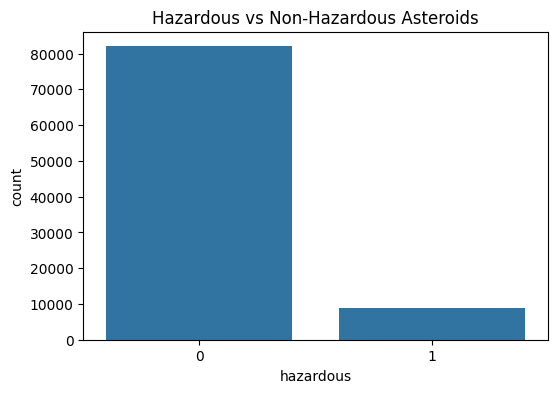

In [50]:
plt.figure(figsize=(6,4))

sns.countplot(x="hazardous", data=df)

plt.title("Hazardous vs Non-Hazardous Asteroids")

plt.show()

In [51]:
df["hazardous"].value_counts(normalize=True)*100

,proportion
hazardous,
0,90.268176
1,9.731824


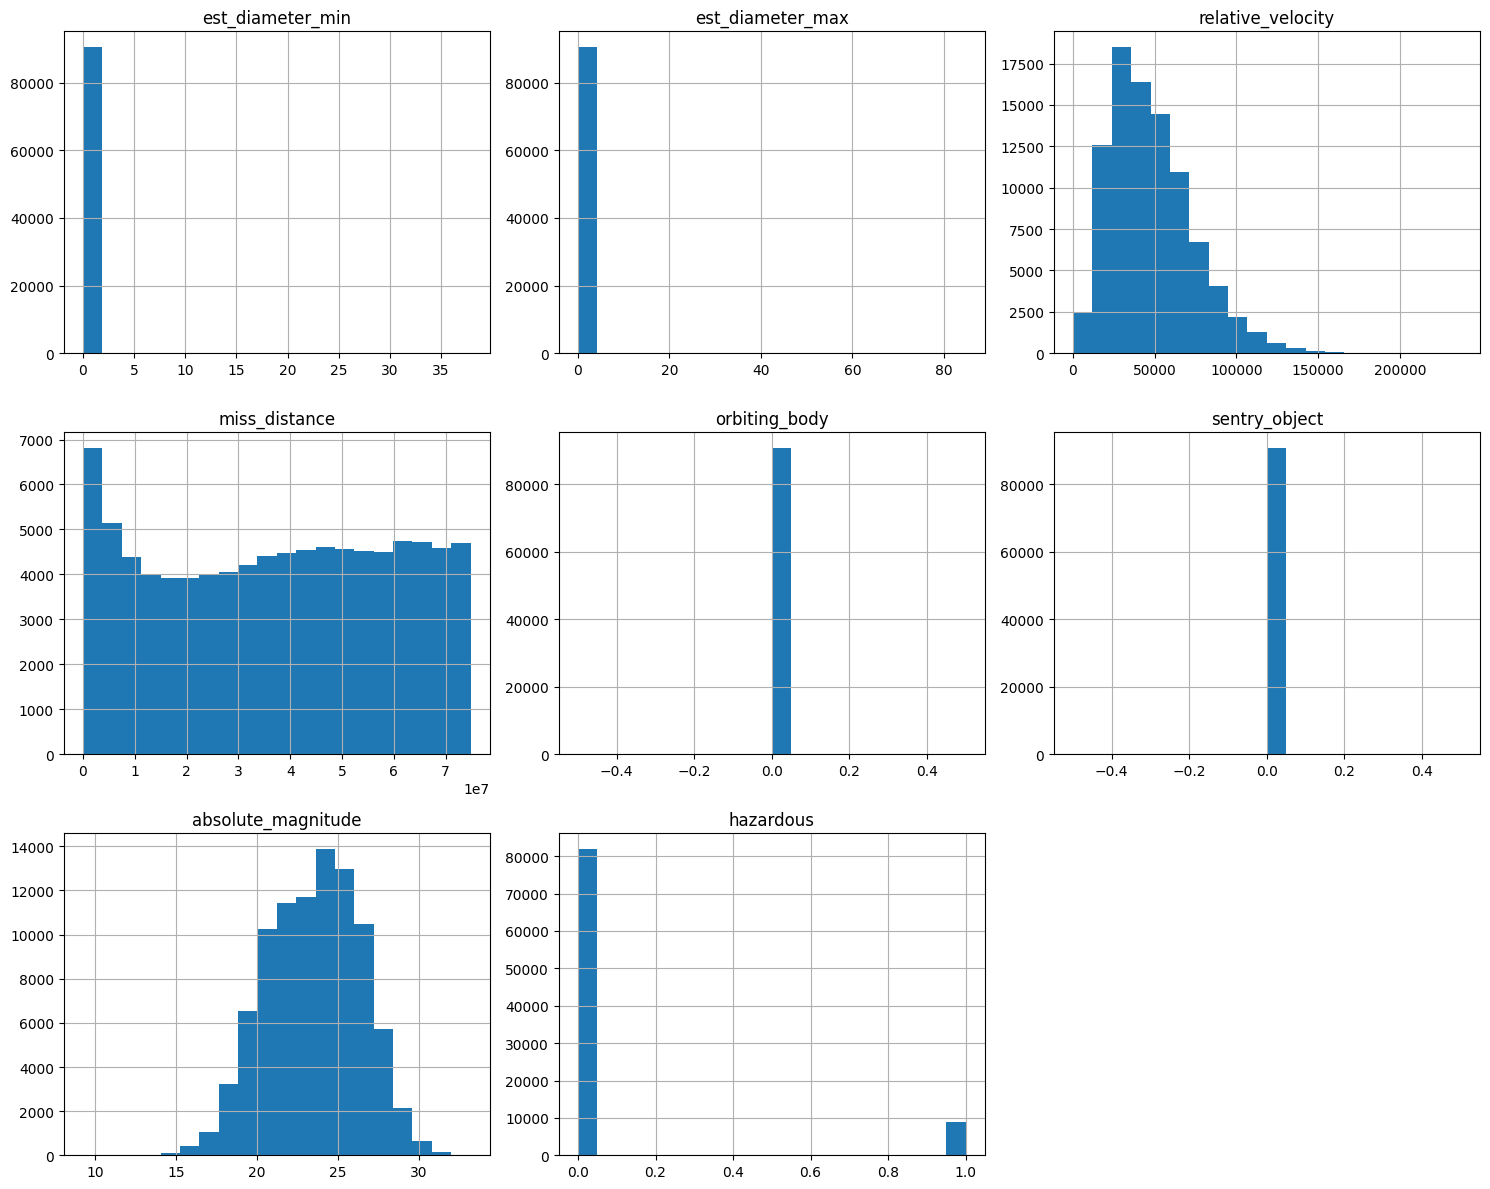

In [52]:
df.hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

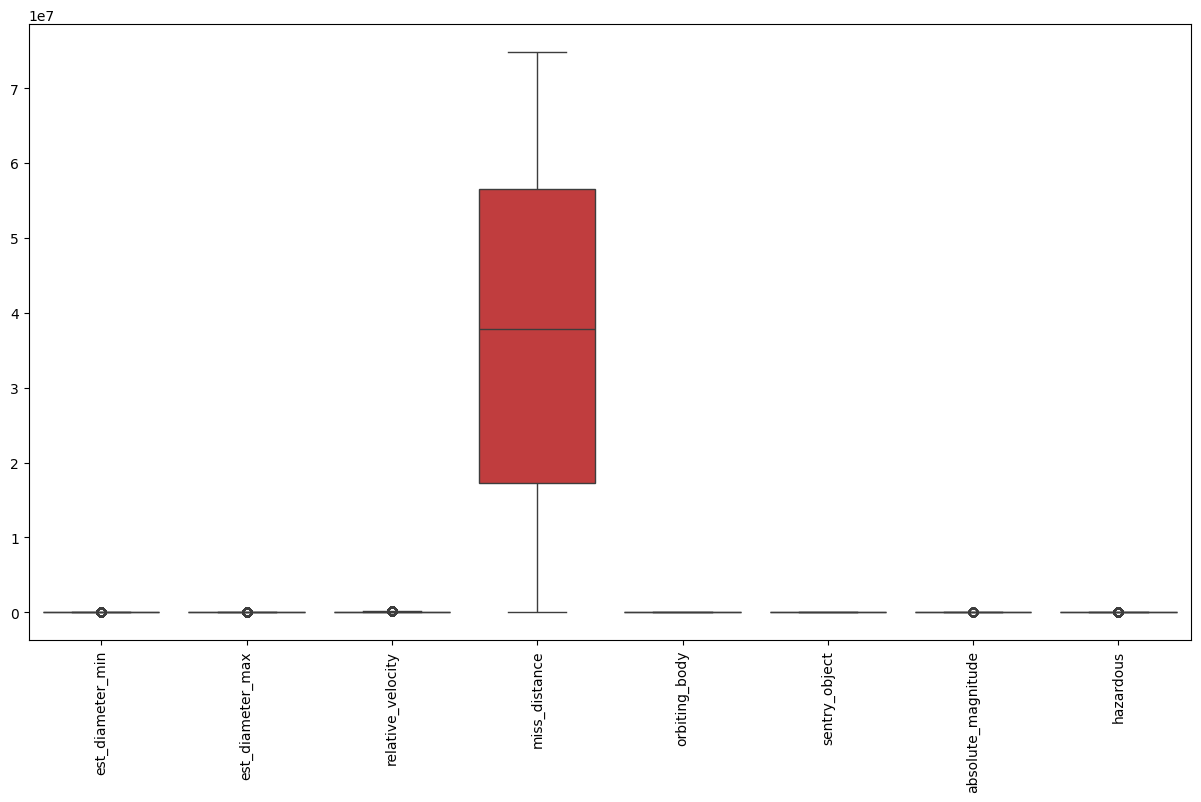

In [53]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [54]:
corr = df.corr(numeric_only=True)

corr

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
est_diameter_min,1.000000,1.000000,0.221553,0.142241,NaN,NaN,-0.560188,0.183363
est_diameter_max,1.000000,1.000000,0.221553,0.142241,NaN,NaN,-0.560188,0.183363
relative_velocity,0.221553,0.221553,1.000000,0.327169,NaN,NaN,-0.353863,0.191185
miss_distance,0.142241,0.142241,0.327169,1.000000,NaN,NaN,-0.264168,0.042302
orbiting_body,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentry_object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
absolute_magnitude,-0.560188,-0.560188,-0.353863,-0.264168,NaN,NaN,1.000000,-0.365267
hazardous,0.183363,0.183363,0.191185,0.042302,NaN,NaN,-0.365267,1.000000


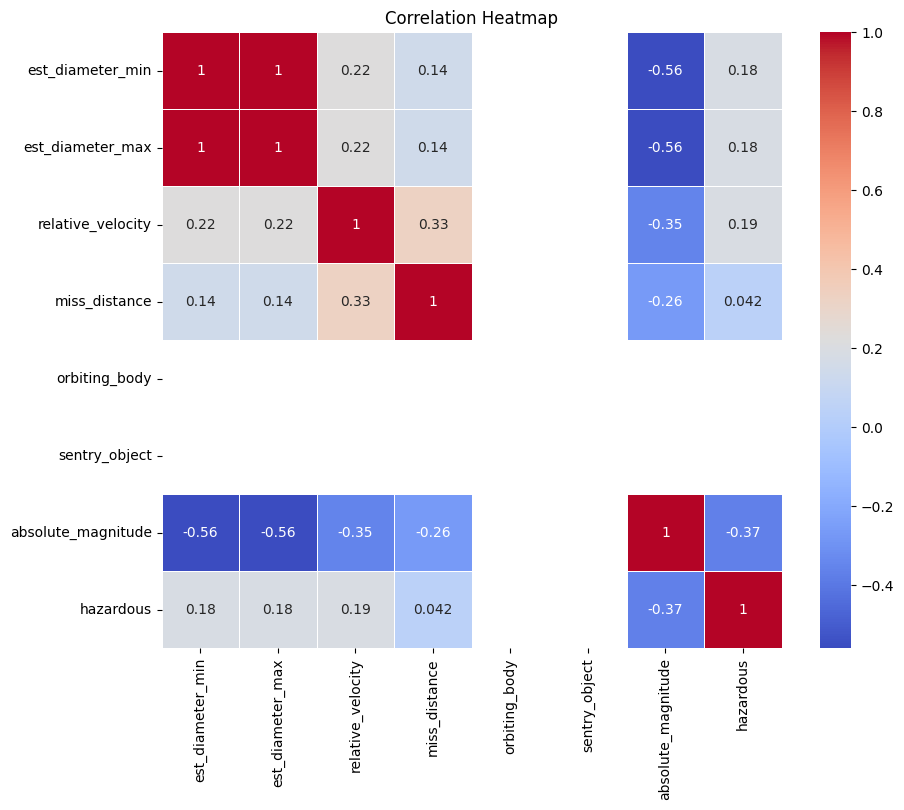

In [55]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

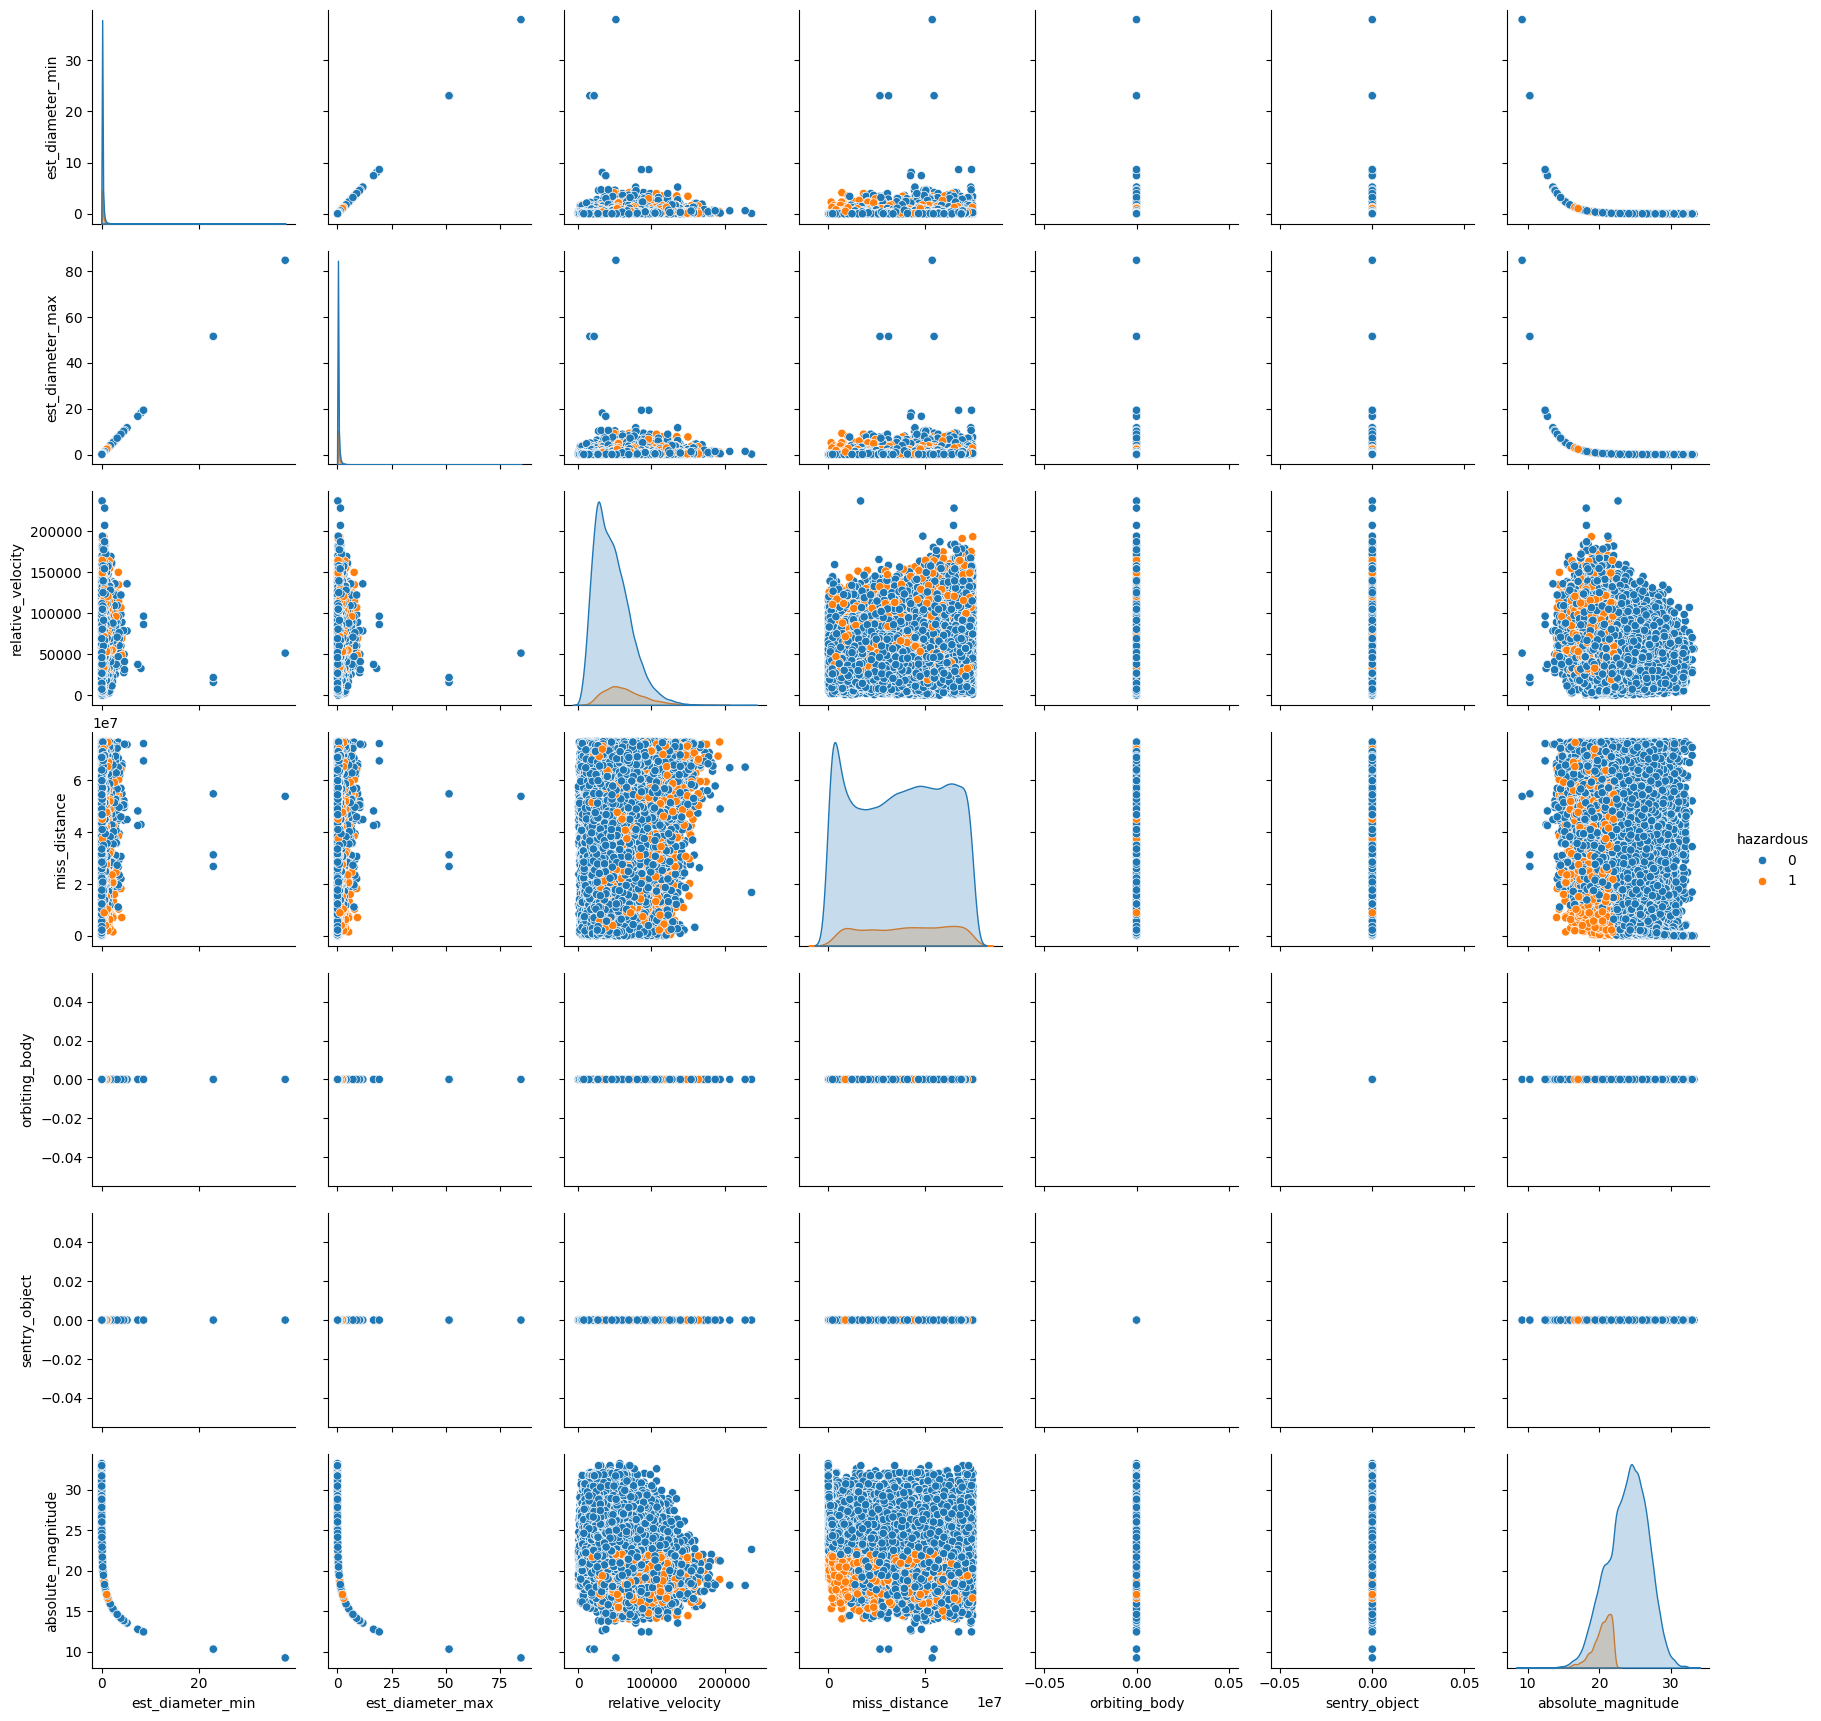

In [56]:
sns.pairplot(df,hue="hazardous")

plt.show()

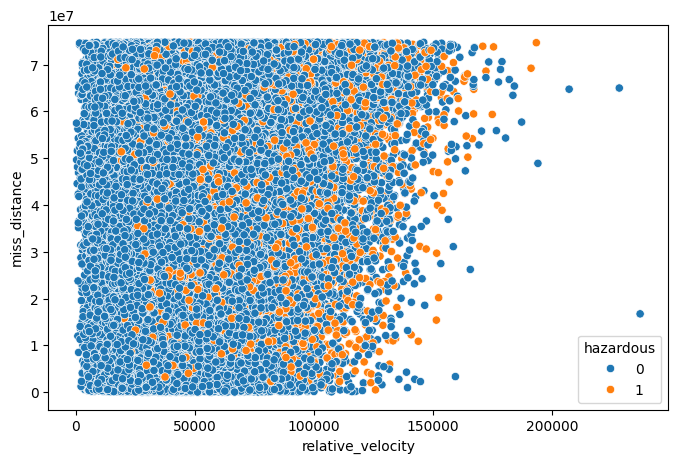

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="relative_velocity",
                y="miss_distance",
                hue="hazardous",
                data=df)

plt.show()

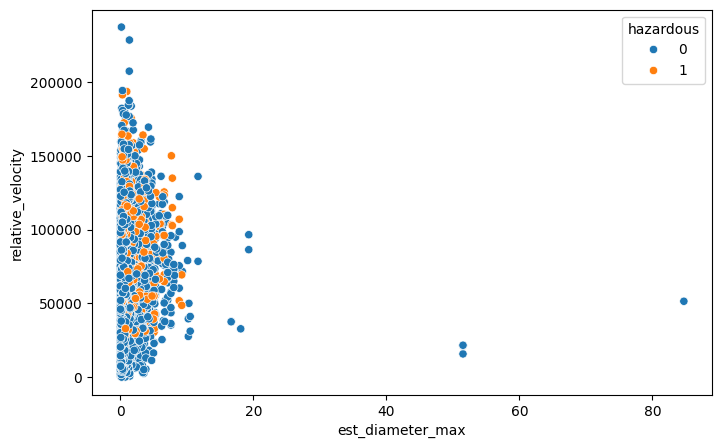

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="est_diameter_max",
                y="relative_velocity",
                hue="hazardous",
                data=df)

plt.show()

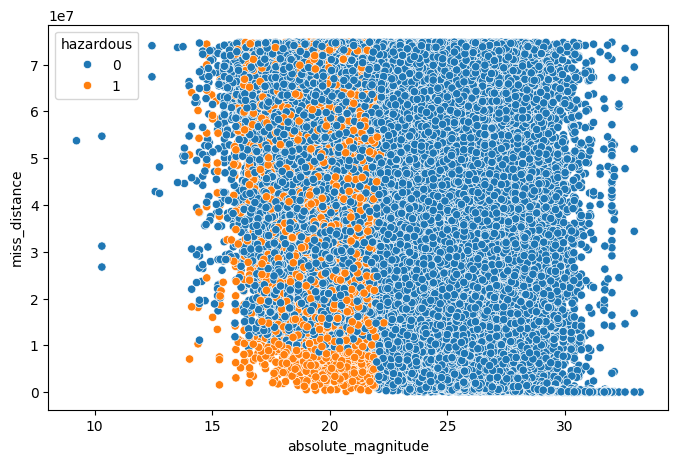

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="absolute_magnitude",
                y="miss_distance",
                hue="hazardous",
                data=df)

plt.show()

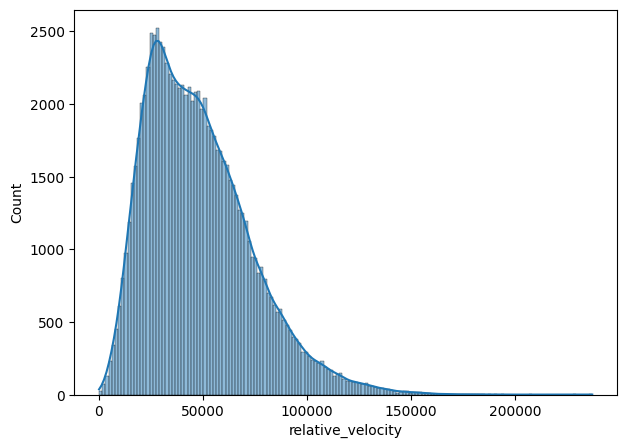

In [60]:
plt.figure(figsize=(7,5))

sns.histplot(df["relative_velocity"],
             kde=True)

plt.show()

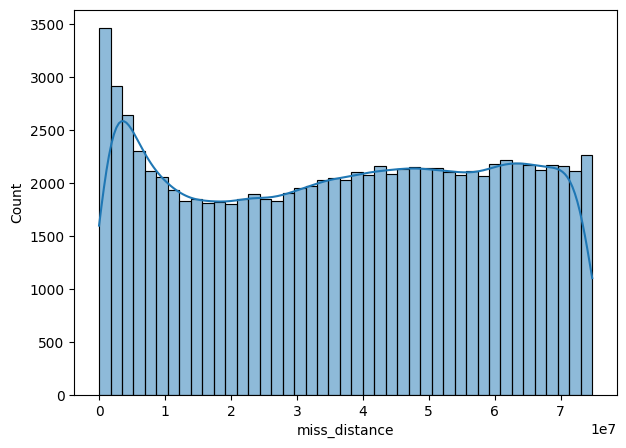

In [61]:
plt.figure(figsize=(7,5))

sns.histplot(df["miss_distance"],
             kde=True)

plt.show()

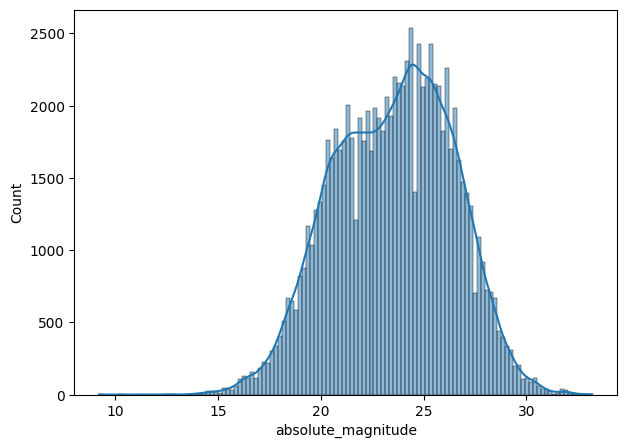

In [62]:
plt.figure(figsize=(7,5))

sns.histplot(df["absolute_magnitude"],
             kde=True)

plt.show()

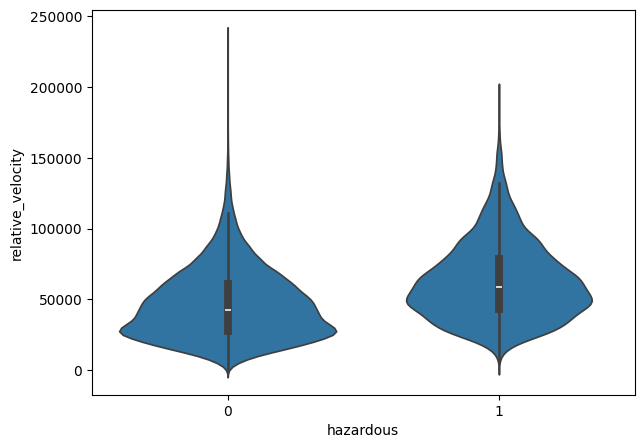

In [63]:
plt.figure(figsize=(7,5))

sns.violinplot(x="hazardous",
               y="relative_velocity",
               data=df)

plt.show()

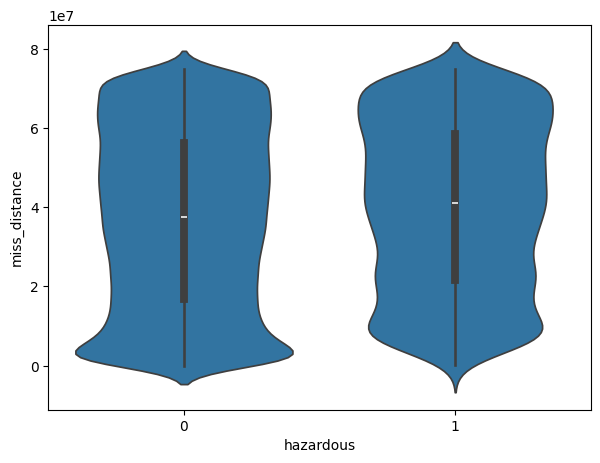

In [64]:
plt.figure(figsize=(7,5))

sns.violinplot(x="hazardous",
               y="miss_distance",
               data=df)

plt.show()

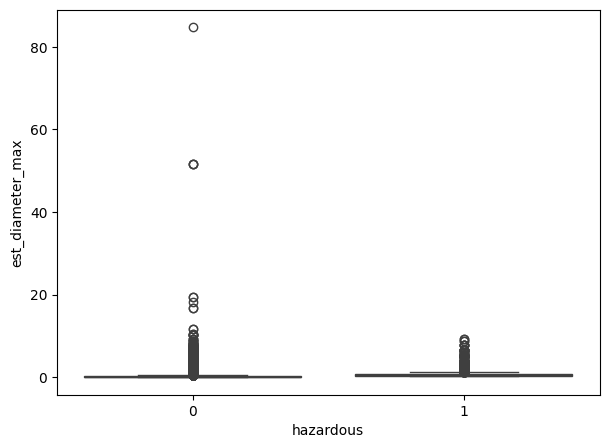

In [65]:
plt.figure(figsize=(7,5))

sns.boxplot(x="hazardous",
            y="est_diameter_max",
            data=df)

plt.show()

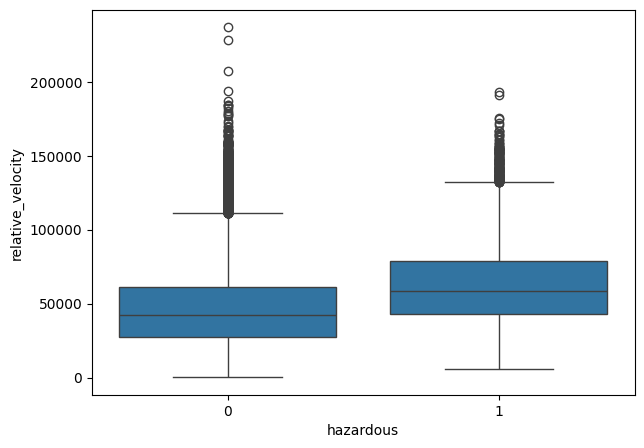

In [66]:
plt.figure(figsize=(7,5))

sns.boxplot(x="hazardous",
            y="relative_velocity",
            data=df)

plt.show()

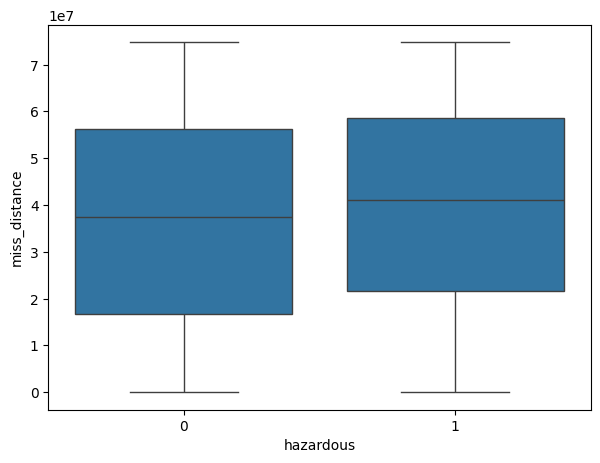

In [67]:
plt.figure(figsize=(7,5))

sns.boxplot(x="hazardous",
            y="miss_distance",
            data=df)

plt.show()

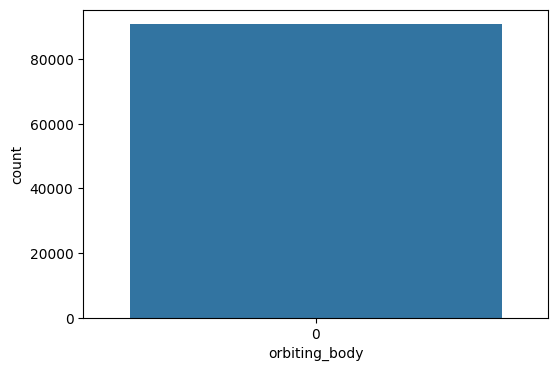

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(x="orbiting_body", data=df)

plt.show()

In [69]:
corr_target = df.corr(numeric_only=True)["hazardous"].sort_values(ascending=False)

print(corr_target)

hazardous             1.000000
relative_velocity     0.191185
est_diameter_max      0.183363
est_diameter_min      0.183363
miss_distance         0.042302
absolute_magnitude   -0.365267
orbiting_body              NaN
sentry_object              NaN
Name: hazardous, dtype: float64


In [70]:
print("EDA Completed Successfully!")

EDA Completed Successfully!


Exploratory Data Analysis Summary

1. The dataset contains both hazardous and non-hazardous asteroids, with non-hazardous objects being more common.

2. Relative velocity, miss distance, estimated diameter, and absolute magnitude show meaningful relationships with hazard classification.

3. The correlation heatmap indicates which numerical features are positively or negatively associated with the target variable.

4. Boxplots and violin plots reveal differences in feature distributions between hazardous and non-hazardous asteroids.

5. These observations support selecting the most informative features for machine learning models.

In [71]:
print(df.columns)

Index(['est_diameter_min', 'est_diameter_max', 'relative_velocity',
       'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude',
       'hazardous'],
      dtype='object')


In [72]:
df.dtypes

,0
est_diameter_min,float64
est_diameter_max,float64
relative_velocity,float64
miss_distance,float64
orbiting_body,int64
sentry_object,int64
absolute_magnitude,float64
hazardous,int64


In [73]:
corr = df.corr(numeric_only=True)

corr["hazardous"].sort_values(ascending=False)

,hazardous
hazardous,1.000000
relative_velocity,0.191185
est_diameter_max,0.183363
est_diameter_min,0.183363
miss_distance,0.042302
absolute_magnitude,-0.365267
orbiting_body,NaN
sentry_object,NaN


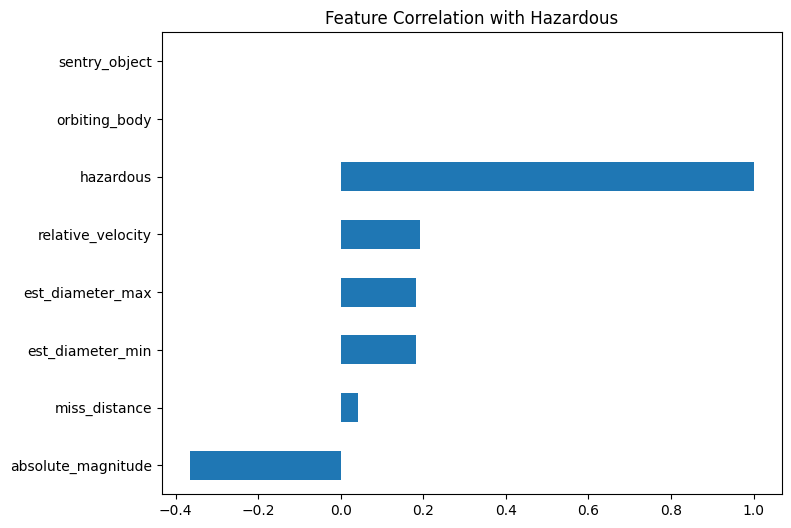

In [74]:
import matplotlib.pyplot as plt

corr["hazardous"].sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Correlation with Hazardous")

plt.show()

In [75]:
features = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "orbiting_body",
    "sentry_object",
    "absolute_magnitude"
]

X = df[features]

y = df["hazardous"]

In [76]:
X.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,1.198271,2.679415,13569.249224,5.483974e+07,0,0,16.73
1,0.265800,0.594347,73588.726663,6.143813e+07,0,0,20.00
2,0.722030,1.614507,114258.692129,4.979872e+07,0,0,17.83
3,0.096506,0.215794,24764.303138,2.543497e+07,0,0,22.20
4,0.255009,0.570217,42737.733765,4.627557e+07,0,0,20.09


In [77]:
y.head()

,hazardous
0,0
1,1
2,0
3,0
4,1


In [78]:
print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (90836, 7)
Target Shape : (90836,)


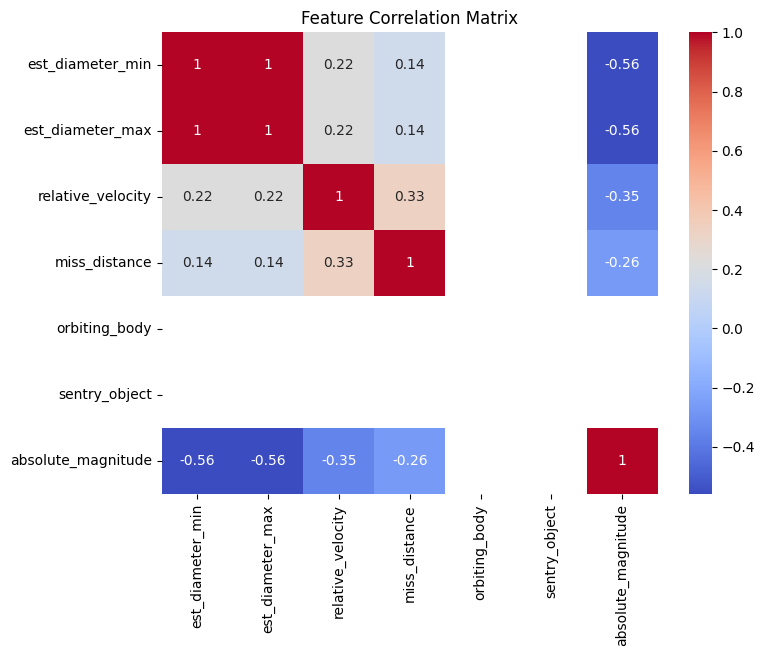

In [79]:
plt.figure(figsize=(8,6))

import seaborn as sns

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [80]:
X.corr()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
est_diameter_min,1.000000,1.000000,0.221553,0.142241,NaN,NaN,-0.560188
est_diameter_max,1.000000,1.000000,0.221553,0.142241,NaN,NaN,-0.560188
relative_velocity,0.221553,0.221553,1.000000,0.327169,NaN,NaN,-0.353863
miss_distance,0.142241,0.142241,0.327169,1.000000,NaN,NaN,-0.264168
orbiting_body,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentry_object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
absolute_magnitude,-0.560188,-0.560188,-0.353863,-0.264168,NaN,NaN,1.000000


In [81]:
X.var()

,0
est_diameter_min,8.910896e-02
est_diameter_max,4.455448e-01
relative_velocity,6.397509e+08
miss_distance,4.996137e+14
orbiting_body,0.000000e+00
sentry_object,0.000000e+00
absolute_magnitude,8.375731e+00


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [83]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
0,3.587284,3.587284,-1.363913,0.795153,0.0,0.0,-2.348632
1,0.463529,0.463529,1.009040,1.090357,0.0,0.0,-1.218735
2,1.991887,1.991887,2.616983,0.569624,0.0,0.0,-1.968544
3,-0.103601,-0.103601,-0.921301,-0.520384,0.0,0.0,-0.458560
4,0.427378,0.427378,-0.210697,0.412001,0.0,0.0,-1.187637


In [84]:
X_scaled.describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude
count,9.083600e+04,9.083600e+04,9.083600e+04,9.083600e+04,90836.0,90836.0,9.083600e+04
mean,-6.070073e-17,9.026887e-17,-1.742017e-16,-1.239046e-16,0.0,0.0,4.552555e-16
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,0.0,0.0,1.000006e+00
min,-4.248547e-01,-4.248547e-01,-1.892353e+00,-1.658014e+00,0.0,0.0,-4.940138e+00
25%,-3.623890e-01,-3.623890e-01,-7.688996e-01,-8.883231e-01,0.0,0.0,-7.557190e-01
50%,-2.648640e-01,-2.648640e-01,-1.532747e-01,3.489782e-02,0.0,0.0,5.974166e-02
75%,5.349850e-02,5.349850e-02,5.873796e-01,8.716232e-01,0.0,0.0,7.508101e-01
max,1.265126e+02,1.265126e+02,7.469341e+00,1.688093e+00,0.0,0.0,3.342317e+00


In [85]:
print(X_scaled.shape)

print(y.shape)

(90836, 7)
(90836,)


In [86]:
processed_df = X_scaled.copy()

processed_df["hazardous"] = y

processed_df.to_csv(
    "processed_neo.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


Feature Engineering Summary

1. Selected the most relevant numerical and encoded categorical features.

2. Removed unnecessary identifier columns (id and name).

3. Converted categorical variables into numerical values using Label Encoding.

4. Standardized all input features using StandardScaler.

5. Created the final feature matrix (X) and target vector (y) for machine learning model development.

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (72668, 7)
Testing Data: (18168, 7)


In [88]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
hazardous
0    65596
1     7072
Name: count, dtype: int64

After SMOTE
hazardous
0    65596
1    65596
Name: count, dtype: int64


In [89]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

In [90]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7861074416556583


In [91]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test)

In [92]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8894209599295465


In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

In [94]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9005394099515632


In [95]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test)

In [96]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8439564068692206


In [97]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.786107
1,Decision Tree,0.889421
2,Random Forest,0.900539
3,XGBoost,0.843956


In [98]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.900539
1,Decision Tree,0.889421
3,XGBoost,0.843956
0,Logistic Regression,0.786107


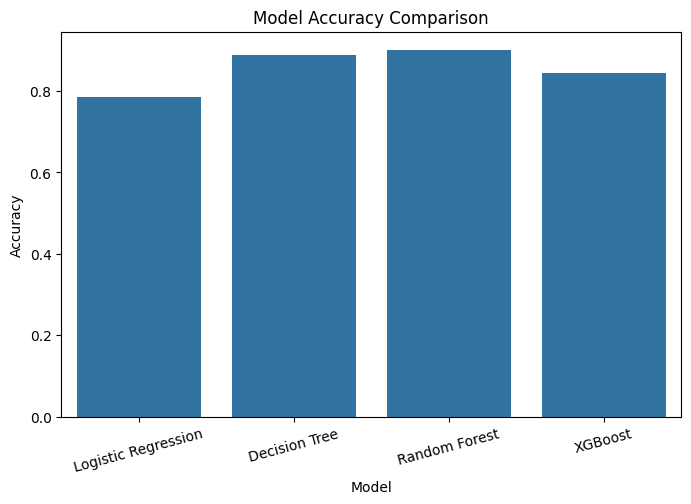

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

In [100]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print(best_model)

Model       Random Forest
Accuracy         0.900539
Name: 2, dtype: object


Model Development Summary

1. Split the dataset into training and testing sets.

2. Applied SMOTE to handle class imbalance.

3. Trained four supervised machine learning models:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • XGBoost

4. Compared the accuracy of all models.

5. Selected the model with the highest accuracy for further evaluation and deployment.

In [101]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9005394099515632


In [102]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94     16400
           1       0.49      0.62      0.55      1768

    accuracy                           0.90     18168
   macro avg       0.72      0.78      0.75     18168
weighted avg       0.91      0.90      0.91     18168



In [103]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[15256  1144]
 [  663  1105]]


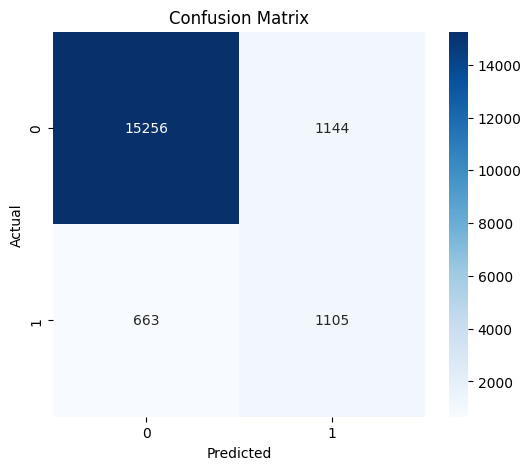

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

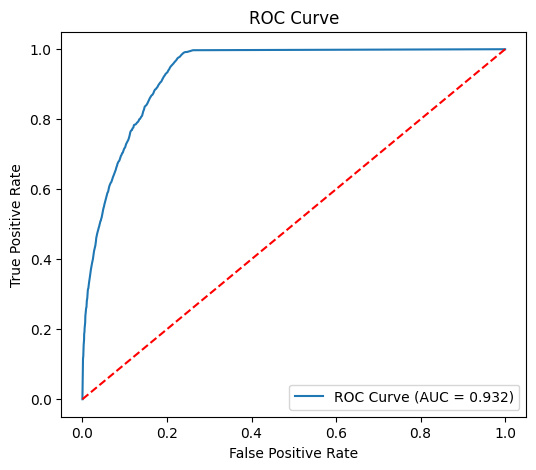

In [105]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [106]:
print("AUC Score:", roc_auc)

AUC Score: 0.9319667910550713


In [107]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance

,Feature,Importance
0,est_diameter_min,0.308692
1,est_diameter_max,0.263699
2,relative_velocity,0.126098
3,miss_distance,0.107804
4,orbiting_body,0.000000
5,sentry_object,0.000000
6,absolute_magnitude,0.193707


In [108]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,est_diameter_min,0.308692
1,est_diameter_max,0.263699
6,absolute_magnitude,0.193707
2,relative_velocity,0.126098
3,miss_distance,0.107804
4,orbiting_body,0.000000
5,sentry_object,0.000000


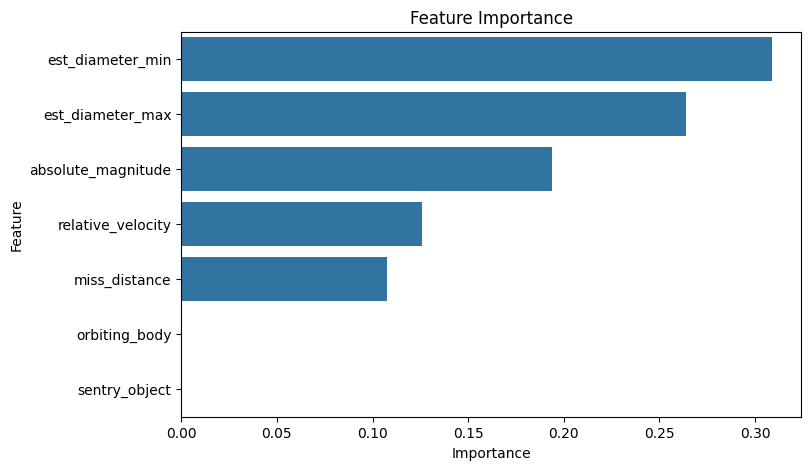

In [109]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [110]:
feature_importance.head()

,Feature,Importance
0,est_diameter_min,0.308692
1,est_diameter_max,0.263699
6,absolute_magnitude,0.193707
2,relative_velocity,0.126098
3,miss_distance,0.107804


In [111]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Prediction : Hazardous Asteroid")
else:
    print("Prediction : Non-Hazardous Asteroid")

Prediction : Non-Hazardous Asteroid


In [112]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [113]:
correct = (comparison["Actual"] == comparison["Predicted"]).sum()

print("Correct Predictions:", correct)

Correct Predictions: 16361


In [114]:
wrong = (comparison["Actual"] != comparison["Predicted"]).sum()

print("Wrong Predictions:", wrong)

Wrong Predictions: 1807


In [115]:
import joblib

joblib.dump(rf, "asteroid_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [116]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


## Model Evaluation & Explainability

1. The Random Forest model achieved the best overall performance among the evaluated classifiers.

2. The confusion matrix indicates that the model correctly classified most hazardous and non-hazardous asteroids.

3. The ROC-AUC score demonstrates the model's ability to distinguish between hazardous and non-hazardous objects.

4. Feature importance analysis shows that Relative Velocity, Miss Distance, Estimated Diameter, and Absolute Magnitude are among the strongest indicators of asteroid hazard.

5. These findings support the use of machine learning for assisting scientists in identifying potentially hazardous Near Earth Objects.